Employment in the US retail sector
We will look at several methods for obtaining the components and later in this chapter, but first it is helpful to see an example. We will decompose the monthly total number of persons in thousands employed in the retail sector across the US since 1990

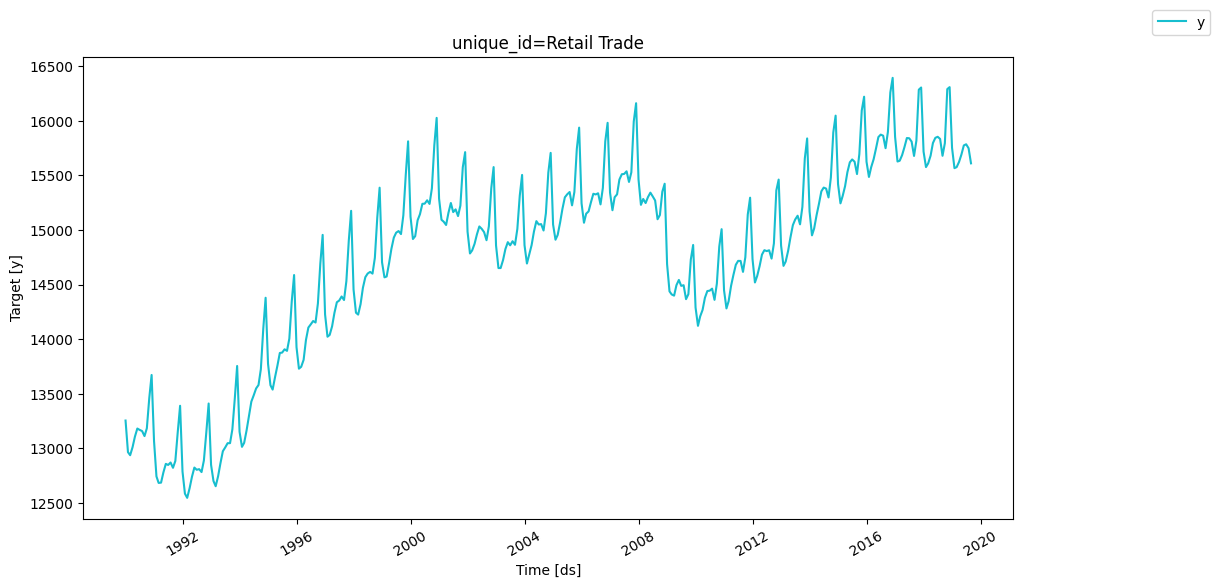

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from utilsforecast.plotting import plot_series
fig,ax=plt.subplots(figsize=(12,6))
us_employement=pd.read_csv("data/us_employment.csv",parse_dates=['ds'])
us_retail_employement=(us_employement.loc[lambda x:(x["unique_id"]=="Retail Trade") & (x["ds"]>="1990")])
plot_series(us_retail_employement,ax=ax)

In [2]:
from statsmodels.tsa.seasonal import STL,seasonal_decompose
import calendar
from coreforecast.scalers import boxcox,boxcox_lambda
stl=STL(us_retail_employement['y'],period=12)
res=stl.fit()
dcmp=pd.DataFrame({
    "ds":us_retail_employement['ds'],
    "data":us_retail_employement['y'],
    "trend":res.trend,
    "seasonal":res.seasonal,
    "reminder":res.resid,  
}).reset_index(drop=True)


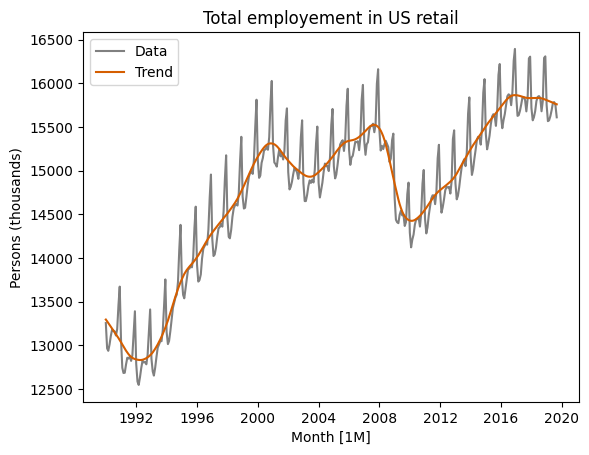

In [3]:
import seaborn as sns
fig,ax=plt.subplots()
sns.lineplot(data=dcmp,x="ds",y="data",color="gray",label="Data")
sns.lineplot(data=dcmp,x="ds",y="trend",color="#D55E00",label="Trend")
ax.set(
    title="Total employement in US retail",
    xlabel="Month [1M]",
    ylabel="Persons (thousands)",
)
plt.show()

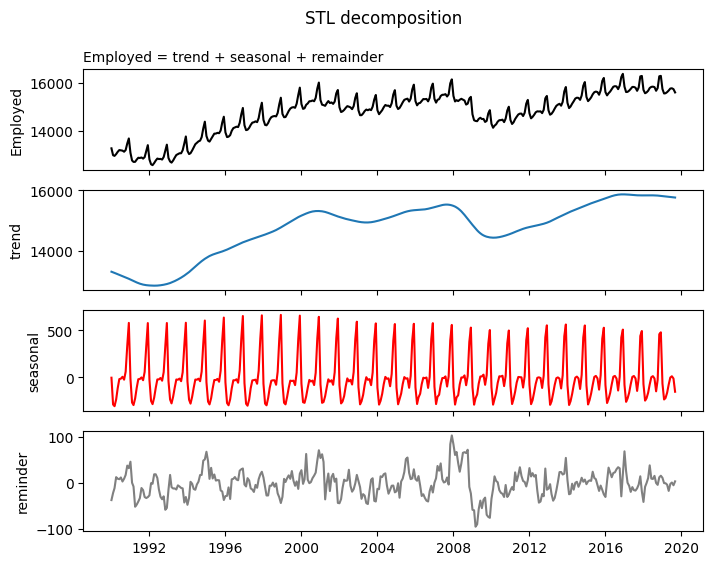

In [4]:
fig,axes=plt.subplots(4,1,sharex=True,figsize=(8,6))
sns.lineplot(data=dcmp,x="ds",y="data",ax=axes[0],color="black")
sns.lineplot(data=dcmp,x="ds",y="seasonal",ax=axes[2],color="red")
sns.lineplot(data=dcmp,x="ds",y="reminder",ax=axes[3],color="grey")
sns.lineplot(data=dcmp,x="ds",y="trend",ax=axes[1])
axes[0].set_title("Employed = trend + seasonal + remainder",size="medium", loc="left")
axes[0].set(ylabel="Employed")
axes[3].set(xlabel="")
fig.suptitle("STL decomposition")
plt.show()


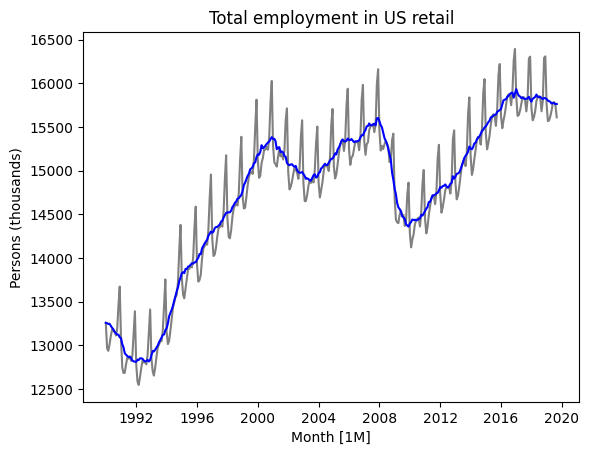

In [7]:
# the data without the Seasonality factor will look like this
df=dcmp.assign(adj=lambda x:x["data"]-x["seasonal"])
fig,ax=plt.subplots()
sns.lineplot(data=df,x="ds",y="data",color="grey")
sns.lineplot(data=df,x="ds",y="adj",color="blue")
ax.set( title="Total employment in US retail",
    xlabel="Month [1M]",
    ylabel="Persons (thousands)",)
plt.show()


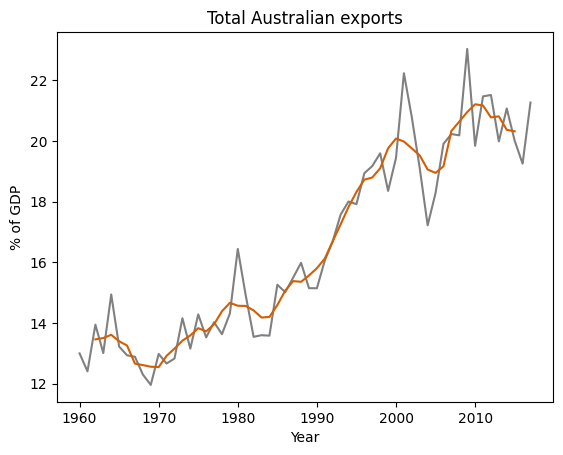

In [8]:
global_econ=pd.read_csv("data/global_economy.csv")
global_aus_econ=global_econ.loc[lambda x:x["unique_id"]=="Australia"]
df=global_econ.loc[lambda x:x["unique_id"]=="Australia"].assign(MA_5=lambda x:x["Exports"].rolling(5,center=True).mean())
fig,ax=plt.subplots()
sns.lineplot(data=global_aus_econ,x="ds",y="Exports",color="grey")
sns.lineplot(data=df,x="ds",y="MA_5",color="#D55E00")
ax.set(
    title="Total Australian exports",
    xlabel="Year",
    ylabel="% of GDP",
)
plt.show()



